# LeetCode #3: Longest Substring Without Repeating Characters

https://leetcode.com/problems/longest-substring-without-repeating-characters/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (All Substrings)** | $O(n^3)$ | $O(\min(n, m))$ |
| **Sliding Window with HashSet** | $O(2n)$ | $O(\min(n, m))$ |
| **Sliding Window with HashMap** | $O(n)$ | $O(\min(n, m))$ |

Where $n$ = string length, $m$ = charset size.

---

## Understanding the Methods

### Brute Force
Check every possible substring ($O(n^2)$ combinations), and for each one verify all characters are unique ($O(n)$). Total: $O(n^3)$.

### Sliding Window with HashSet
Use two pointers to define a window. When the right pointer hits a duplicate, remove characters from the left one-by-one until the duplicate is gone. Each character is added and removed at most once, so time is $O(2n)$ worst case.

### Optimal: Sliding Window with HashMap ★
Instead of removing characters one-by-one, store each character's last seen index in a hash map. When a duplicate is found, jump the left pointer directly past the previous occurrence. This avoids the inner removal loop entirely.

**Why this is better than HashSet:** Both are $O(n)$ amortized, but the HashMap version does exactly $n$ iterations with no inner loop. The HashSet version can visit the same character twice (once to add, once to remove), giving $O(2n)$ in the worst case.

**Constraints:**
* $0 \le$ s.length $\le 5 \times 10^4$
* `s` consists of English letters, digits, symbols, and spaces.

## Solutions

### C#

In [ ]:
using System;
using System.Collections.Generic;

public class Solution {
    public int LengthOfLongestSubstring(string s) {
        // Dictionary to store the character and its last seen index
        Dictionary<char, int> map = new Dictionary<char, int>();
        int maxLength = 0;
        int left = 0;

        for (int right = 0; right < s.Length; right++) {
            char current = s[right];

            // If character exists in current window, move left pointer
            if (map.ContainsKey(current) && map[current] >= left) {
                left = map[current] + 1;
            }

            // Update the index of the character
            map[current] = right;
            
            // Maximize the length (right - left + 1 is the current window size)
            maxLength = Math.Max(maxLength, right - left + 1);
        }

        return maxLength;
    }
}

### Python

In [ ]:
class Solution:
    def lengthOfLongestSubstring(self, s: str) -> int:
        # Dictionary to store the character and its last seen index
        char_map = {}
        max_length = 0
        left = 0

        for right, current in enumerate(s):
            # If character exists in current window, move left pointer
            if current in char_map and char_map[current] >= left:
                left = char_map[current] + 1

            # Update the index of the character
            char_map[current] = right

            # Maximize the length (right - left + 1 is the current window size)
            max_length = max(max_length, right - left + 1)

        return max_length

### Go

In [ ]:
func lengthOfLongestSubstring(s string) int {
    // Map to store the character and its last seen index
    charMap := make(map[byte]int)
    maxLength := 0
    left := 0

    for right := 0; right < len(s); right++ {
        current := s[right]

        // If character exists in current window, move left pointer
        if idx, ok := charMap[current]; ok && idx >= left {
            left = idx + 1
        }

        // Update the index of the character
        charMap[current] = right

        // Maximize the length (right - left + 1 is the current window size)
        if right-left+1 > maxLength {
            maxLength = right - left + 1
        }
    }

    return maxLength
}

### Rust

In [ ]:
use std::collections::HashMap;

impl Solution {
    pub fn length_of_longest_substring(s: String) -> i32 {
        // HashMap to store the character and its last seen index
        let mut char_map: HashMap<u8, usize> = HashMap::new();
        let mut max_length = 0;
        let mut left = 0;
        let bytes = s.as_bytes();

        for (right, &current) in bytes.iter().enumerate() {
            // If character exists in current window, move left pointer
            if let Some(&idx) = char_map.get(&current) {
                if idx >= left {
                    left = idx + 1;
                }
            }

            // Update the index of the character
            char_map.insert(current, right);

            // Maximize the length (right - left + 1 is the current window size)
            max_length = max_length.max(right - left + 1);
        }

        max_length as i32
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `s = "abcabcbb"`  
The window expands to "abc" (length 3), then 'a' repeats — left jumps forward. No later window exceeds 3.  
**Result:** `3` ("abc")

### 2. Slightly Complex: Non-Adjacent Duplicate
**Input:** `s = "pwwkew"`  
At R=5, 'w' was last seen at index 1 but L is already at 2. The `map[current] >= left` check prevents L from jumping backward — it stays at 3 instead of resetting to 2.  
**Result:** `3` ("wke" or "kew")

### 3. Edge Case: Time Factor (All Unique)
**Input:** `s = "abcdefgh"`  
No duplicates exist, so L never moves. The window grows to cover the entire string in one pass. This is the best case for time — exactly $n$ map inserts, zero jumps.  
**Result:** `8`

### 4. Edge Case: Space Factor (All Same Character)
**Input:** `s = "bbbbb"`  
Every character is a duplicate. The map only ever holds 1 entry — the best case for space. L chases R on every step, so the window never exceeds size 1.  
**Result:** `1`

### 5. Almost-Impossible but Plausible: Late Duplicate of Early Character
**Input:** `s = "abcdefga"`  
The only duplicate is the very last character referencing the very first. L jumps from 0 to 1 — the window barely shrinks (7 to 7). Tests whether the algorithm correctly updates 'a' in the map while keeping L at `max(L, old+1)`.  
**Result:** `7`

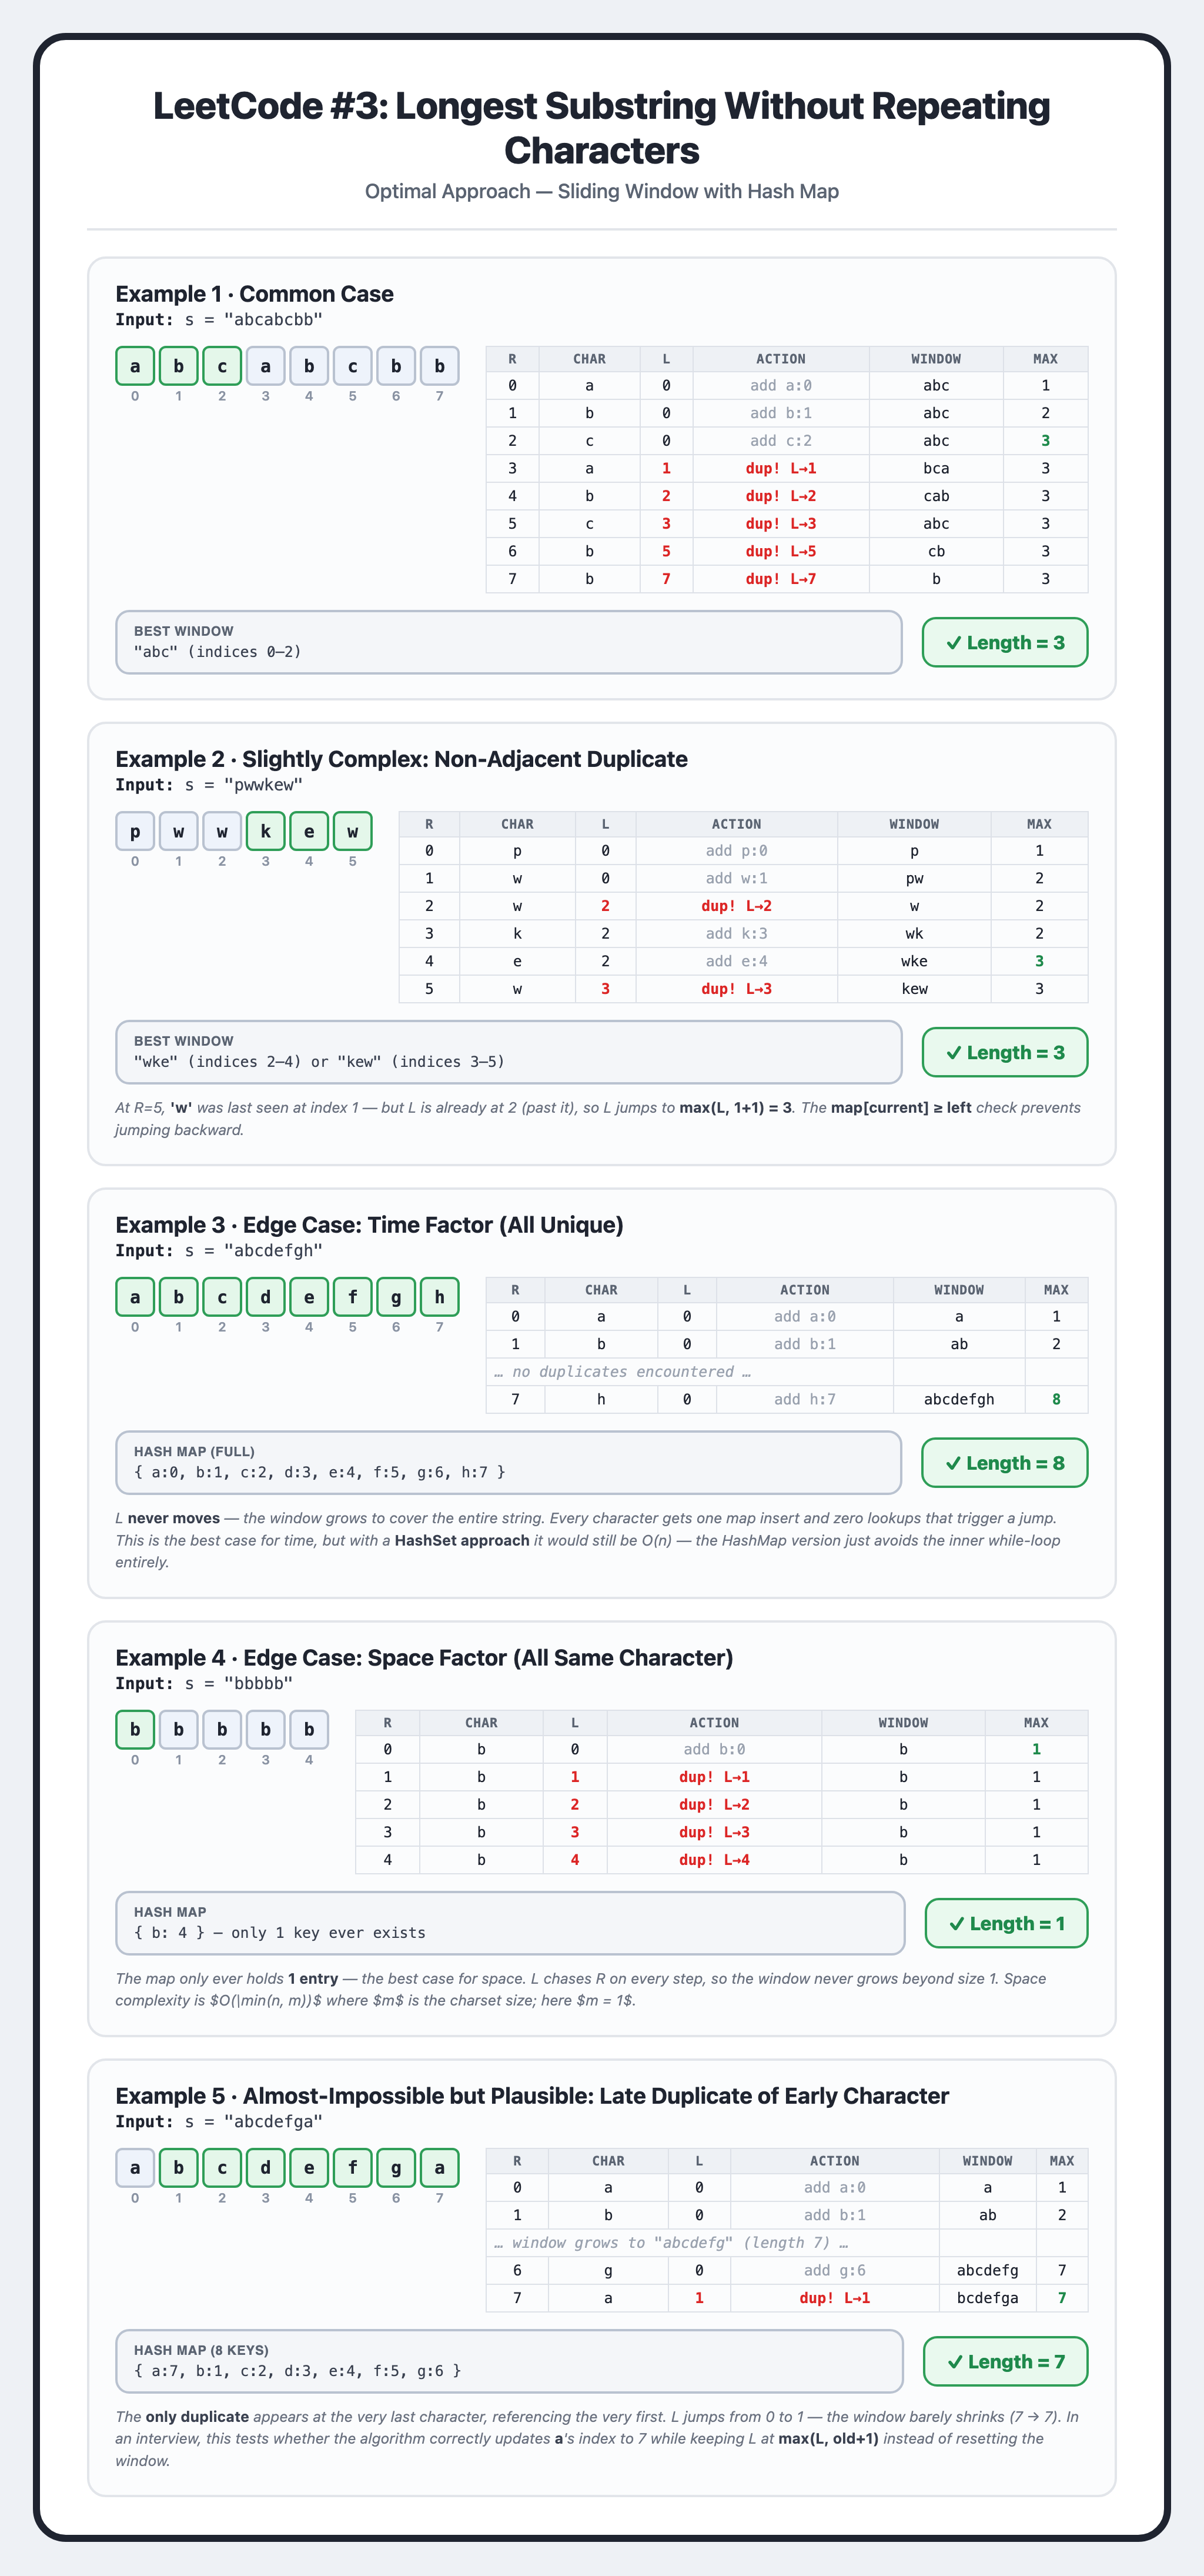